# The Cancer Genome Atlas (TCGA) Breast Invasive Carcinoma (BRCA) Dataset

This dataset measures the genetic and biological effect of BRCA in a cohort of 1000+ patients. 

For this project we have subset this dataset with common and unique patients across three datasets : 
 - Transcriptomcs (mRNA)
 - Epigentics (DNAm)
 - Proteomics (RPPA)

The prediction taks in this project is tumour subtype classification. It has been shown that, depending on the specific tumour subtype, outcomes for women with BRCA will vary significantly. Therefore, being able to accruately stratify by subtype is an important characterisation for this cancer and will affect the treatment course decided by the physician. 

The different subtypes present in this dataset are : 
- Luminal A (LumA)
- Luminal B (LumB)
- Basal
- HER2

Each of these modalities will capture a different aspect of the disease, thus many methods which can integrate them have become popular. 

In this short notebook, we will look at the different data types and give some information on their biological aspects. 

In [94]:
# Load important libraries and data
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from palettable import wesanderson as wes
from matplotlib_venn import venn3
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap
import plotly.express as px
data_dir = "./../data/TCGA-BRCA/"
mod = ["mRNA", "DNAm" , "RPPA"]

In [95]:
data = {}
for omic in mod : 
   with open(f"{data_dir}{omic}.pkl", "rb") as f:  # 'rb' = read binary
    data[omic] = pickle.load(f) 

## Transcriptomics (mRNA)

Transcriptomics looks at all RNA in a cell to see which genes are “on” and how strongly.

This gene expression dataset is a table of gene activity levels across breast cancer (BRCA) tissue samples

Numbers come from RNA sequencing; higher values mean more of that gene’s RNA was detected.

mRNA and genes should have a very similar distribution in a population, but when a person has a disease, the disease can cause a large change in a genes expression causing it to become over/under expressed. 

In [96]:
data['mRNA']["expr"].head()

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288611.1,ENSG00000288612.1,ENSG00000288638.1,ENSG00000288648.1,ENSG00000288657.1,ENSG00000288658.1,ENSG00000288663.1,ENSG00000288670.1,ENSG00000288674.1,ENSG00000288675.1
TCGA-E9-A228,11.220890,4.194486,10.680243,10.487409,9.448297,9.408937,10.505433,11.871306,10.985411,11.401380,...,3.308428,5.408347,2.843467,2.843467,2.843467,6.249685,5.485041,8.864766,4.498478,4.194486
TCGA-HN-A2NL,12.279388,3.347630,11.422199,10.338415,9.834559,8.123745,10.559379,10.412459,10.856693,11.637981,...,4.373216,4.732522,3.552924,2.843467,2.843467,6.432414,5.938534,8.195267,4.879134,6.307971
TCGA-OL-A5D7,11.436488,4.204181,11.338812,10.696614,11.024408,9.917112,9.852083,10.494274,10.290863,12.049691,...,3.469872,6.238882,2.843467,2.843467,2.843467,5.977719,5.808513,9.188112,4.707533,6.365531
TCGA-A2-A3KC,11.511191,5.737801,10.834398,10.931552,9.698790,9.609320,11.893211,11.046319,10.422642,11.226144,...,3.354080,5.578962,2.843467,3.561911,2.843467,4.064020,5.762593,8.621993,4.459940,5.431014
TCGA-A2-A0YI,12.431769,5.762581,10.823070,10.601755,8.992869,9.630460,11.674870,11.553497,11.183243,11.169297,...,3.506481,5.608277,2.843467,3.314332,2.843467,3.773210,5.460744,8.646323,4.210609,4.343591


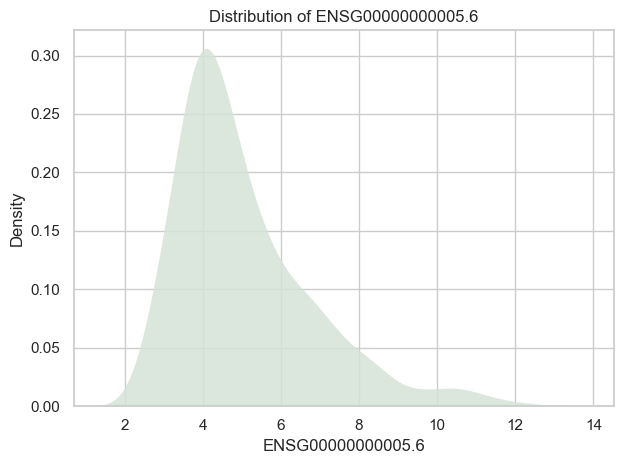

In [97]:
color = wes.Darjeeling2_5.mpl_colors[0]  # pick a color from the palette

gene = data['mRNA']["expr"].columns[1]

sns.set(style="whitegrid")
sns.kdeplot(data=data['mRNA']["expr"], x=f"{gene}", fill=True, color=color, alpha=0.85, linewidth=0)
plt.xlabel(f"{gene}")
plt.ylabel("Density"); 
plt.title(f"Distribution of {gene}")
plt.tight_layout()
plt.show()

## Epigentics (DNAm)

Epigenetics studies chemical tags on DNA sites that control gene activity without changing the DNA sequence.

DNA methylation is one such tag (adding methyl groups), referred to as CpGs,  that often reduces gene activity.

A DNA methylation dataset measures how much methylation is present at many genomic sites across samples.

These tags are crucial in aging for example, to stop us growing taller and taller indefinitely.

DNAm is a very useful measure for how we interact with out environment as the number and location of specific chemical tags can tell us if and how much someone consumes alcohol, smokes, works with pesticides, exposure to carcinogenics etc...  

In [98]:
data['DNAm']["expr"].head()

,cg11738485,cg01893212,cg21885317,cg12466610,cg15690342,cg22473620,cg02467990,cg23179456,cg04131969,cg22831607,...,cg00592510,cg06459913,cg01749500,cg17985854,cg16023912,cg03407594,cg07290865,cg06153893,cg10262891,cg07132590
TCGA-E9-A228,0.960700,0.644724,0.964877,0.589824,0.663511,0.649849,0.647587,0.693198,0.352195,0.726499,...,0.144670,0.758155,0.756128,0.684074,0.753583,0.695458,0.886056,0.728452,0.822799,0.788491
TCGA-HN-A2NL,0.583237,0.023547,0.966170,0.058889,0.073499,0.056420,0.020411,0.843894,0.026822,0.024529,...,0.095880,0.940490,0.817412,0.744143,0.891167,0.734321,0.852952,0.281028,0.422452,0.964047
TCGA-OL-A5D7,0.021655,0.035954,0.979647,0.828104,0.124674,0.072108,0.031360,0.025608,0.927734,0.731654,...,0.080530,0.945476,0.681666,0.447804,0.832570,0.843092,0.911593,0.045209,0.614898,0.951736
TCGA-A2-A3KC,0.031399,0.472174,0.613586,0.579223,0.709417,0.655372,0.410265,0.658779,0.925193,0.583415,...,0.291444,0.904078,0.618604,0.366992,0.781996,0.700943,0.868345,0.098596,0.664794,0.953521
TCGA-A2-A0YI,0.491925,0.544880,0.640366,0.592854,0.845361,0.639998,0.445780,0.555931,0.506736,0.675618,...,0.084366,0.930467,0.641724,0.589872,0.695018,0.746382,0.907000,0.028049,0.753637,0.964383


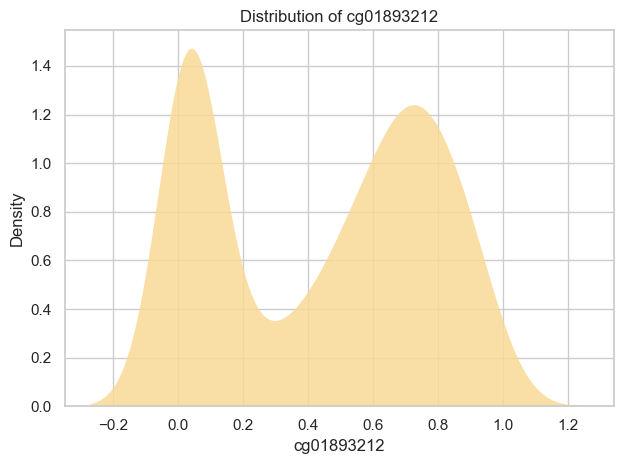

In [99]:
color = wes.Darjeeling2_5.mpl_colors[2]  # pick a color from the palette

cpg = data['DNAm']["expr"].columns[1]

sns.set(style="whitegrid")
sns.kdeplot(data=data['DNAm']["expr"], x=f"{cpg}", fill=True, color=color, alpha=0.85, linewidth=0)
plt.xlabel(f"{cpg}")
plt.ylabel("Density"); 
plt.title(f"Distribution of {cpg}")
plt.tight_layout()
plt.show()

## Proteomics (RPPA)

Proteomics studies all the proteins in a cell or tissue—what’s there and how much.

The proteomics dataset we are using is Reverse Phase Protein Array (RPPA). This dataset is a table of protein abundance levels across the tumour tissue samples.

It is measure by microscope technologies by tagging proteins in the samples with a chemical dye and quantifying how much of each protein is present by their illuminaiton. 

Proteomics is really useful to get an accurate pin-point snapshop of the biology of the tumour in its measured state. The downside is that protein measurements are sparse across patient samples with many missing samples as not every protein will be abundant in each patient. How you handle this artefact will be an important consideration in your analyses and could effect different models differently. 

In [100]:
data['RPPA']["expr"].head()

,1433BETA,1433EPSILON,1433ZETA,4EBP1,4EBP1_pS65,4EBP1_pT37T46,4EBP1_pT70,53BP1,ACC_pS79,ACC1,...,XPF,XRCC1,YAP,YAP_pS127,YB1,YB1_pS102,YTHDF2,YTHDF3,ZAP-70,ZEB1
TCGA-E9-A228,-0.011293,-0.060878,-0.202675,1.35820,0.020965,0.312617,0.102329,0.204165,0.604385,0.32035,...,0.231692,0.020158,-0.342985,-0.776035,0.057015,-0.340385,-0.099780,0.110625,-0.697522,0.226013
TCGA-HN-A2NL,0.252110,0.080503,0.197350,-0.29719,-0.374150,0.463070,-0.407030,-0.941850,0.765260,0.47086,...,0.579617,-0.424650,0.331740,0.371280,-0.220320,0.131920,-0.752445,-1.048190,0.480243,0.760178
TCGA-OL-A5D7,-0.014454,0.026866,-0.334580,0.67399,-0.605530,-0.491210,-0.009052,-0.384940,-0.186570,-0.56132,...,0.100363,0.100020,-0.020238,-0.605830,-0.676840,-0.154990,0.508370,-0.157935,2.031538,0.245044
TCGA-A2-A3KC,0.106510,0.241750,0.303230,-0.28122,-0.586760,-0.853800,-0.406400,-0.079820,0.155410,0.14472,...,-0.038458,0.101470,-0.074459,0.048927,-0.382870,-0.273140,-0.599380,-0.461275,0.632358,0.339843
TCGA-A2-A0YI,0.008400,0.101940,0.379810,-0.45383,-0.438570,-0.091300,-0.181230,0.489960,0.822000,0.58515,...,1.028037,0.167430,-0.351550,-0.286540,-0.432520,-0.194490,-0.290635,-0.340180,0.842933,0.077968


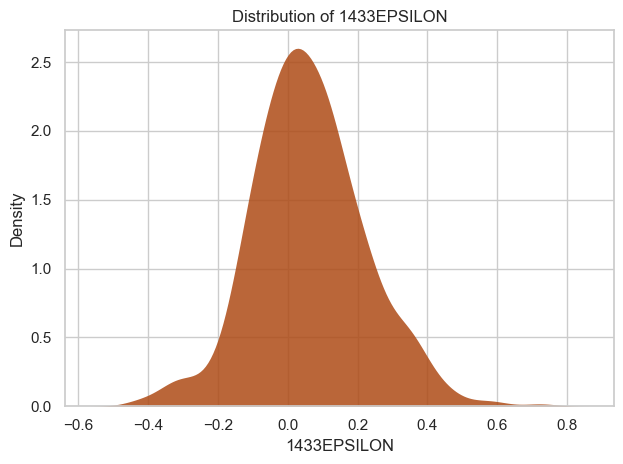

In [101]:
color = wes.Darjeeling2_5.mpl_colors[3]  # pick a color from the palette

prtn = data['RPPA']["expr"].columns[1]

sns.set(style="whitegrid")
sns.kdeplot(data=data['RPPA']["expr"], x=f"{prtn}", fill=True, color=color, alpha=0.85, linewidth=0)
plt.xlabel(f"{prtn}")
plt.ylabel("Density"); 
plt.title(f"Distribution of {prtn}")
plt.tight_layout()
plt.show()

## Analyse the number of patiens, features in each omic dataset, dataset overlapping,presence of missing values, class proportions

In [102]:
# -------------------------------------------------------
# 1. Load metadata for each omics dataset
# -------------------------------------------------------
# Extract the metadata tables for mRNA, DNA methylation (DNAm), and RPPA from the data dictionary
mRNA_df = data['mRNA']['meta']
DNAm_df = data['DNAm']['meta']
RPPA_df = data['RPPA']['meta']

In [103]:
# -------------------------------------------------------
# 2. Identify patients common to all three omics datasets
# -------------------------------------------------------
# Use pandas isin() to filter patients that are present in mRNA, DNAm, and RPPA datasets

common_all = mRNA_df[
    (mRNA_df['patient'].isin(DNAm_df['patient'])) &
    (mRNA_df['patient'].isin(RPPA_df['patient']))
].copy()

# Print the number of patients and columns shared across all three datasets
print("All three datasets:", common_all.shape)

# -------------------------------------------------------
# 3. Identify patients common to each pair of datasets
# -------------------------------------------------------
# mRNA and DNAm
common_mrna_dnam = mRNA_df[mRNA_df['patient'].isin(DNAm_df['patient'])].copy()
print("mRNA and DNAm:", common_mrna_dnam.shape)

# mRNA and RPPA
common_mrna_rppa = mRNA_df[mRNA_df['patient'].isin(RPPA_df['patient'])].copy()
print("mRNA and RPPA:", common_mrna_rppa.shape)

# DNAm and RPPA
common_dnam_rppa = DNAm_df[DNAm_df['patient'].isin(RPPA_df['patient'])].copy()
print("DNAm and RPPA:", common_dnam_rppa.shape)

All three datasets: (401, 7)
mRNA and DNAm: (415, 7)
mRNA and RPPA: (414, 7)
DNAm and RPPA: (414, 5)


In [104]:
# -------------------------------------------------------
# 4. Calculate the total number of unique patients across all datasets
# -------------------------------------------------------
# Concatenate the metadata from all three datasets to get a full list of patients

total_df = pd.concat([data['mRNA']['meta'], data['DNAm']['meta']])
total_df = pd.concat([total_df, data['RPPA']['meta']])


# Count the number of unique patients
n_unique_patients = total_df['patient'].nunique()
print(f"Number of unique patients: {n_unique_patients}")

Number of unique patients: 658


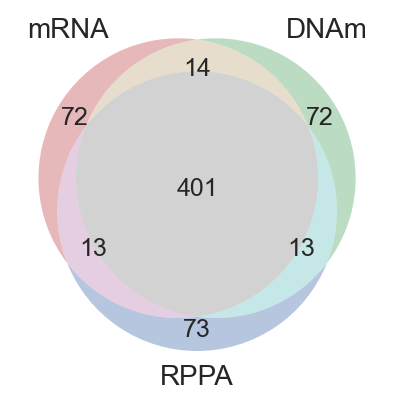

In [105]:
# -------------------------------------------------------
# 5. Visualize patient overlap using a Venn diagram
# -------------------------------------------------------
# Use matplotlib_venn to plot the intersections of patients across the three omics datasets


plt.figure()

out = venn3(subsets=[set(data['mRNA']['meta']['patient']),
               set(data['DNAm']['meta']['patient']),
               set(data['RPPA']['meta']['patient'])],
      set_labels=mod)

for text in out.set_labels:
    text.set_fontsize(20)
for text in out.subset_labels:
    text.set_fontsize(18)

plt.show()
# The diagram shows the number of patients shared between all three datasets and between pairs

Most of the patients (401 out of 658) have data available for all three omics. Forty patients lack data for one of the three omics, and 217 patients lack data for two of the three omics.

## Check for nans (missing values)

In [106]:
# -------------------------------------------------------
# 6. Check for missing values (NaNs) in both expression and metadata tables
# -------------------------------------------------------
# For each omics dataset and for both the expression ('expr') and metadata ('meta') tables

keys = ['expr', 'meta']
for omic in mod:
    for key in keys:
        df = data[omic][key].copy()          # Make a copy of the dataset
        df = df[df.isna().any(axis=1)]      # Filter rows containing any NaN values
        print(f"For {omic} and {key}: {df.shape[0]}")
# This ensures data completeness; here, all datasets have zero missing values

For mRNA and expr: 0
For mRNA and meta: 0
For DNAm and expr: 0
For DNAm and meta: 0
For RPPA and expr: 0
For RPPA and meta: 0


In our three-omics dataset, there are no missing values in the expression or metadata.

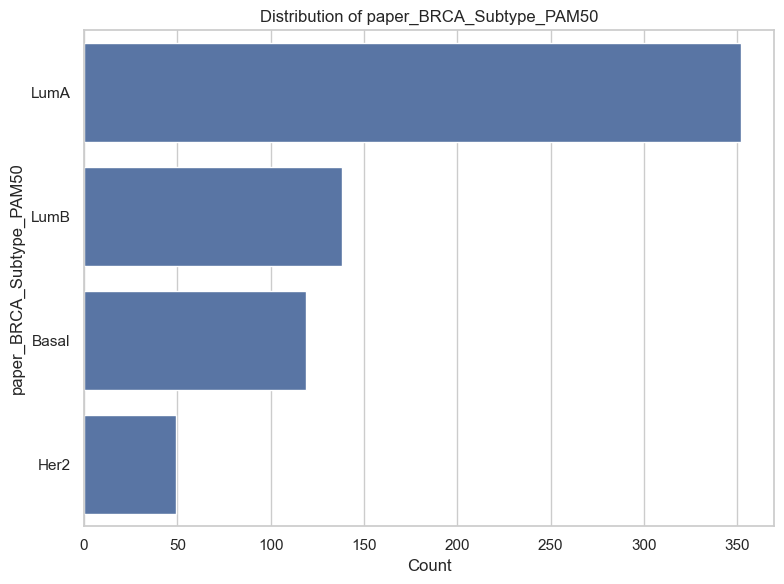

In [107]:

# -------------------------------------------------------
# Combine metadata from all omics datasets
# -------------------------------------------------------
# Concatenate the metadata tables from mRNA, DNAm, and RPPA datasets into one DataFrame
# ignore_index=False keeps the original indices (optional here)
df_all_meta = pd.concat([data['mRNA']["meta"], data['DNAm']["meta"], data['RPPA']["meta"]], ignore_index=False)
# Remove duplicate rows based on the "patient" column to keep unique patients only
df_all_meta = df_all_meta.drop_duplicates(subset="patient")

# -------------------------------------------------------
# Define categorical columns for visualization
# -------------------------------------------------------
categorical_cols = ['paper_BRCA_Subtype_PAM50']

# -------------------------------------------------------
# Plot the distribution of categorical variables
# -------------------------------------------------------
plt.figure(figsize=(8, 6))  # Adjusted for one plot

# Loop over each categorical column and create a subplot with a horizontal countplot
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, len(categorical_cols), i)
    order = df_all_meta[col].value_counts().index  # Get order by frequency
    sns.countplot(y=col, data=df_all_meta, order=order)
    plt.title(f"Distribution of {col}")
    plt.xlabel("Count")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

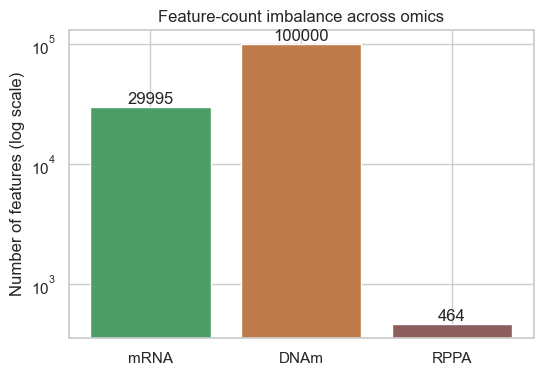

In [108]:

# Define omics types and count the number of features for each
omics = ['mRNA', 'DNAm', 'RPPA']
feature_counts = [
    data['mRNA']["expr"].shape[1],  # Number of mRNA features
    data['DNAm']["expr"].shape[1],  # Number of DNA methylation features
    data['RPPA']["expr"].shape[1]   # Number of protein features
]

# Create a figure with specified size
plt.figure(figsize=(6,4))

# Create a bar plot with custom colors
bars = plt.bar(omics, feature_counts, color=['#4c9d67', '#c07b4c', '#8c5d5d'])

# Set y-axis to logarithmic scale to better visualize large differences
plt.yscale('log')

# Add title and y-axis label
plt.title("Feature-count imbalance across omics")
plt.ylabel("Number of features (log scale)")

# Annotate each bar with its feature count value
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', 
             ha='center', va='bottom')

# Display the plot
plt.show()


### Analysis of global distributions for the 3 omics

Sampled down to 200000 points for plotting
Sampled down to 200000 points for plotting
Sampled down to 200000 points for plotting


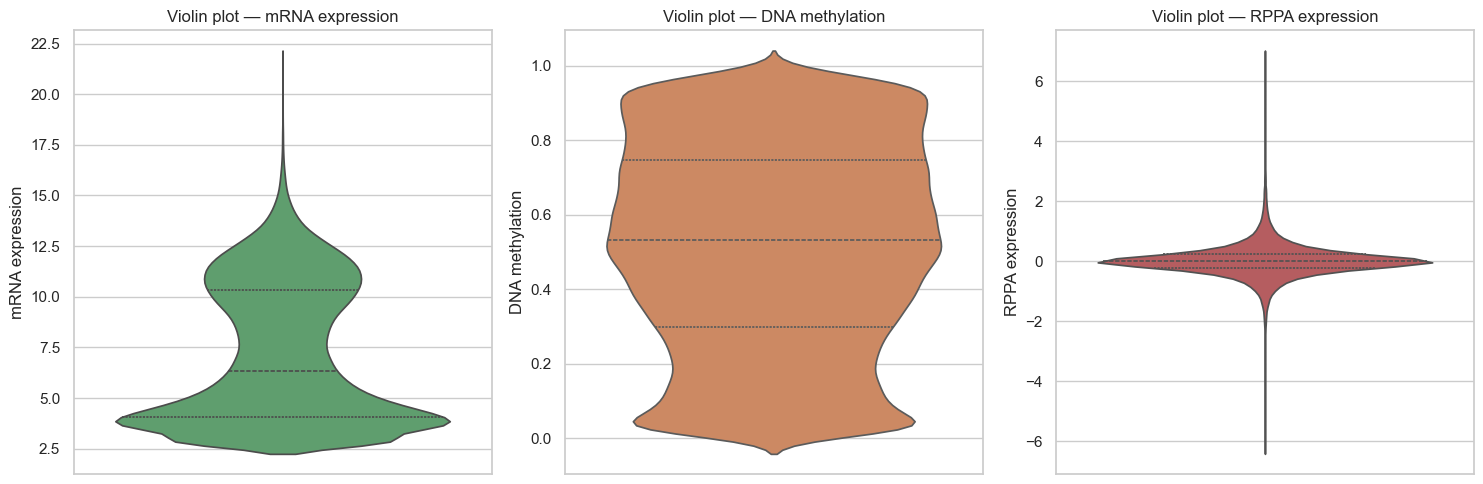

In [109]:

# Copy the expression matrices from the data dictionary for each omic type
mRNA_expr = data['mRNA']['expr'].copy()
DNAm_expr = data['DNAm']['expr'].copy()
RPPA_expr = data['RPPA']['expr'].copy()

# Function to plot a violin plot from a given omic expression matrix
def plot_violin_from_matrix(expr, label="expression", sample_max=200000, color="C2", figsize=(4,6)):
    """
    Plots a violin plot for a given omic expression matrix.
    
    Parameters:
    - expr: pandas DataFrame containing the expression values
    - label: label for the y-axis and plot title
    - sample_max: maximum number of points to plot (for large datasets)
    - color: color of the violin
    - figsize: figure size (width, height)
    """
    
    # Flatten the matrix into a 1D vector
    vec = expr.to_numpy().ravel()
    
    # Downsample if too many points for efficient plotting
    if vec.size > sample_max:
        rng = np.random.default_rng(42)  # Set seed for reproducibility
        vec = rng.choice(vec, size=sample_max, replace=False)
        print(f"Sampled down to {vec.size} points for plotting")
    
    # Create a DataFrame suitable for seaborn violin plot
    df_violin = pd.DataFrame({label: vec})
    
    # Create figure if none exists
    if not plt.get_fignums():
        plt.figure(figsize=figsize)
    
    # Plot violin plot with quartiles indicated inside
    sns.violinplot(y=label, data=df_violin, inner="quartile", color=color)
    plt.title(f"Violin plot — {label}")
    plt.ylabel(label)
    plt.tight_layout()

# Create a 1x3 subplot to plot each omic side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot mRNA expression violin plot on first axis
plt.sca(axes[0])
plot_violin_from_matrix(mRNA_expr, label="mRNA expression", color="C2")

# Plot DNA methylation violin plot on second axis
plt.sca(axes[1])
plot_violin_from_matrix(DNAm_expr, label="DNA methylation", color="C1")

# Plot RPPA expression violin plot on third axis
plt.sca(axes[2])
plot_violin_from_matrix(RPPA_expr, label="RPPA expression", color="C3")

# Adjust layout to prevent overlapping elements and display the plots
plt.tight_layout()
plt.show()


The distribution of mRNA expression levels (on the left) across all genes and samples shows similarities to a right-skewed distribution with a long tail, meaning that most genes have low expression levels while only a minority have higher expression levels. The presence of two peaks suggests two groups of genes: one large group with low expression levels around 3, and a smaller group with higher expression levels around 11.

The distribution of DNA methylation levels (in the center) shows strong variability across sites and patients, indicating diverse methylation patterns.

The distribution of protein abundance levels (RPPA) (on the right) displays a symmetric, approximately Gaussian profile centered around zero, which reflects that the abundance values have been normalized. Most proteins have similar abundance levels (close to zero after normalization, likely representing the mean or median), while only a few proteins show abundance levels significantly above or below the overall mean.

## Comparison of the 3 distributions

mRNA: sampled down to 200000 points for plotting (from 14997500)
DNAm: sampled down to 200000 points for plotting (from 50000000)
RPPA: sampled down to 200000 points for plotting (from 232000)


/var/folders/p2/lnfl0k0d5zd3lw9c13j04vzh0000gn/T/ipykernel_25871/443326499.py:30: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




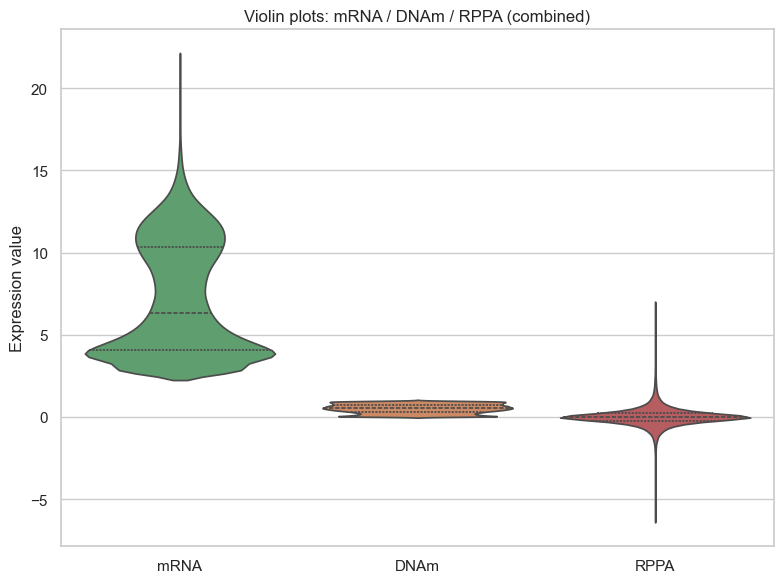

In [110]:
# Function to flatten a matrix or array into a 1D vector
def _flatten(arr):
    return np.asarray(arr).ravel()

max_points = 200000
rng = np.random.default_rng(42)  # Random generator with fixed seed for reproducibility

# Prepare lists to store flattened values and corresponding omic labels
all_vecs = []
all_labels = []

# Loop over each omic dataset to flatten and optionally downsample
for name, df in [("mRNA", mRNA_expr), ("DNAm", DNAm_expr), ("RPPA", RPPA_expr)]:
    v = _flatten(df)              # Flatten the expression matrix
    original_n = v.size
    # Downsample if number of points exceeds max_points
    if original_n > max_points:
        v = rng.choice(v, size=max_points, replace=False)
        print(f"{name}: sampled down to {v.size} points for plotting (from {original_n})")
    all_vecs.append(v)             # Store flattened/downsampled vector
    all_labels.extend([name] * v.size)  # Store corresponding labels for plotting

# Combine all vectors into a single array for plotting
combined = np.concatenate(all_vecs)
df_combined = pd.DataFrame({"omic": all_labels, "expression": combined})

# Create a figure for the combined violin plot
plt.figure(figsize=(8,6))
# Plot violin plot with quartiles, one violin per omic type
sns.violinplot(x="omic", y="expression", data=df_combined, inner="quartile", palette=["C2", "C1", "C3"])
plt.title("Violin plots: mRNA / DNAm / RPPA (combined)")
plt.ylabel("Expression value")
plt.xlabel("")
plt.tight_layout()
plt.show()

The datas from the three omics presents similar and thus comparable scale

## Exploratory Data Analysis (mRNA) (Transcriptomics)

There are  500  patients and  29995  features (genes) in the mRNA expression data.


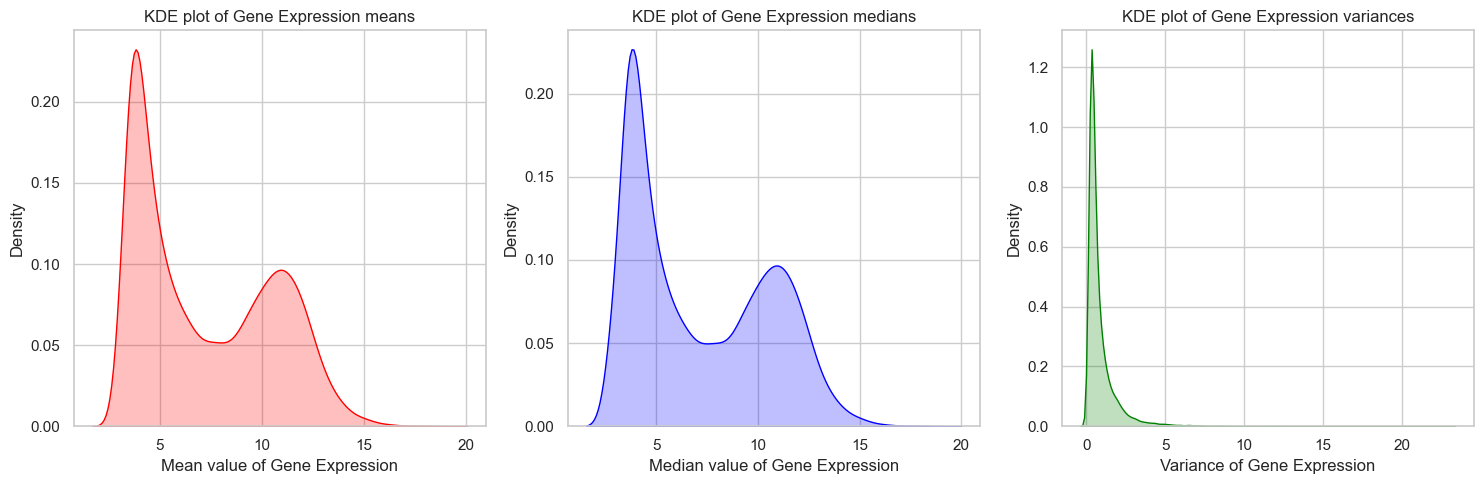

In [111]:
# Copy the mRNA expression and metadata for analysis
mRNA_expr = data['mRNA']['expr'].copy()
mRNA_meta = data['mRNA']['meta'].copy()

# Print basic dataset dimensions: number of patients (rows) and genes/features (columns)
print("There are ", mRNA_expr.shape[0], " patients and ", mRNA_expr.shape[1], " features (genes) in the mRNA expression data.")

# Compute column-wise statistics for the mRNA expression matrix
mRNA_col_means = mRNA_expr.mean(axis=0)      # Mean expression per gene
mRNA_col_medians = mRNA_expr.median(axis=0)  # Median expression per gene
mRNA_col_var = mRNA_expr.var(axis=0)         # Variance of expression per gene

# Create a 1x3 subplot for KDE plots of means, medians, and variances
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot KDE of gene-wise means
plt.sca(axes[0])
sns.kdeplot(mRNA_col_means, fill=True, color='red')
plt.title("KDE plot of Gene Expression means")
plt.xlabel("Mean value of Gene Expression")
plt.ylabel("Density")

# Plot KDE of gene-wise medians
plt.sca(axes[1])
sns.kdeplot(mRNA_col_medians, fill=True, color='blue')
plt.title("KDE plot of Gene Expression medians")
plt.xlabel("Median value of Gene Expression")
plt.ylabel("Density")

# Plot KDE of gene-wise variances
plt.sca(axes[2])
sns.kdeplot(mRNA_col_var, fill=True, color='green')
plt.title("KDE plot of Gene Expression variances")
plt.xlabel("Variance of Gene Expression")
plt.ylabel("Density")

# Adjust layout and display the plots
plt.tight_layout()
plt.show()


We can observe two populations of genes: a large one with low expression levels (around 3) and a smaller one with higher expression levels (peak around 11). All genes shows very similar variance meaning that it is independant from the mean and thus that we respect homoscedasticity conditions.

## PCA

Variance explained by first two components :
[0.14516502 0.1002925 ]


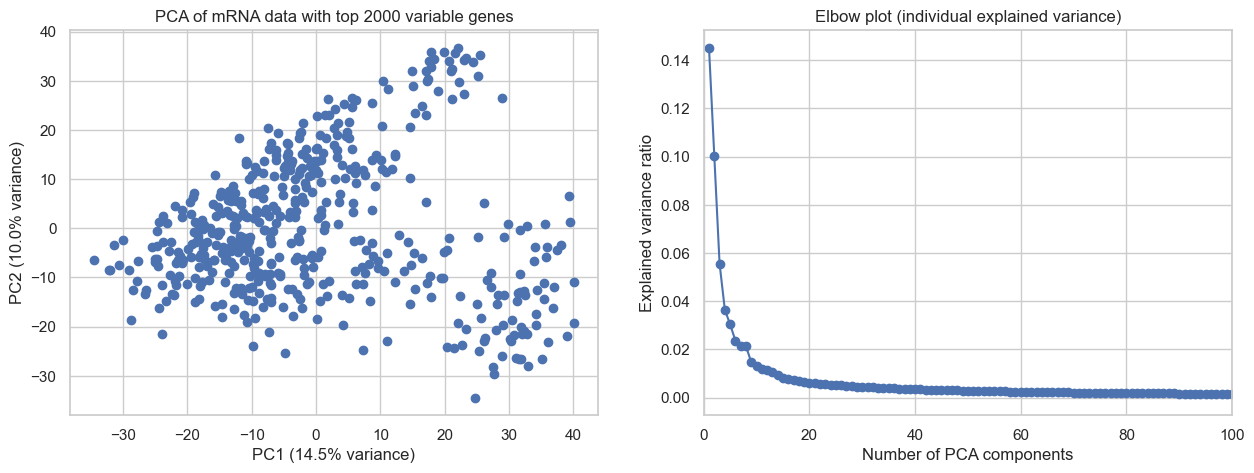

In [112]:
# Extract mRNA expression data
mRNA_df = data['mRNA']['expr']

# Select top 2000 most variable genes
top__indices = np.argsort(data['mRNA']['expr'].var(axis=0))[-2000:][::-1]                
mRNA_df = mRNA_df.iloc[:, top__indices]

# Standardize the data: mean=0, variance=1 for each gene
scaler = StandardScaler()
mRNA_scaled = scaler.fit_transform(mRNA_df)



# Perform PCA and reduce to 20 principal components
pca = PCA(n_components=15)
principal_components = pca.fit_transform(mRNA_scaled)

# PCA for elbow plot
n_samples = mRNA_scaled.shape[0]

pca_ = PCA(n_components=min(n_samples, mRNA_scaled.shape[1]))
pca_.fit(mRNA_scaled)
explained_var = pca_.explained_variance_ratio_  # Variance explained by each component

# Print variance explained by the first two principal components
print("Variance explained by first two components :")
print(pca.explained_variance_ratio_[:2])

# Create a 1x2 subplot: scatter plot of first two PCs and elbow plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter plot of first two principal components
plt.sca(axes[0])
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA of mRNA data with top 2000 variable genes")
plt.grid(True)

# Elbow plot: visualize explained variance for each PCA component
plt.sca(axes[1])
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o', linestyle='-')
plt.title("Elbow plot (individual explained variance)")
plt.xlabel("Number of PCA components")
plt.ylabel("Explained variance ratio")
plt.xlim(0, 100)
plt.grid(True)


## UMAP

In [113]:
# Extract mRNA expression data
mRNA_df = data['mRNA']['expr']

# Top 2000 variables genes
top_indices = np.argsort(mRNA_df.var(axis=0))[-2000:][::-1]                
mRNA_df = mRNA_df.iloc[:, top_indices]


# Standardize the data: mean=0, variance=1 for each protein
scaler = StandardScaler()
mRNA_scaled = scaler.fit_transform(mRNA_df)

# Reduce dimensionality with PCA before UMAP (retain top 10 components)
pca = PCA(n_components=15, random_state=42)
mRNA_pca = pca.fit_transform(mRNA_scaled)

# Apply UMAP for 2D embedding of the PCA-reduced data
reducer_1 = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
mRNA_umap2d = reducer_1.fit_transform(mRNA_pca)

# Create a DataFrame with UMAP coordinates and PAM50 subtype labels
umap_df_2d = pd.DataFrame(
    mRNA_umap2d,
    columns=['UMAP1', 'UMAP2'],
    index=mRNA_df.index
)
umap_df_2d['paper_BRCA_Subtype_PAM50'] = data['mRNA']['meta'].loc[umap_df_2d.index, 'paper_BRCA_Subtype_PAM50']

# Create an interactive 2D scatter plot using Plotly, coloring points by PAM50 breast cancer subtype
fig = px.scatter(
    umap_df_2d,
    x='UMAP1',
    y='UMAP2',
    color='paper_BRCA_Subtype_PAM50',
    labels={'paper_BRCA_Subtype_PAM50': 'PAM50 Subtype'},
    title='UMAP of mRNA data colored by PAM50 subtype',
    opacity=0.8,
    width=800,
    height=500
)
fig.update_layout(title_font_size=30, legend_title_font_size=24, legend_font_size=20, font=dict(size=18))
fig.show()


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



We can globally observe three clusters. Basal subtype tumours show a very different profile in terme of genes expression (cluster far away from other) from other subtypes. The other tumour subtype Lum A, Lum B and Her present very similar profiles in term of gene expression (their cluster are very near one from the other and overlap). This confirms the need of more advance machine learning techniques in order to distinguish them. We do not observe any strong outliers (i.e., samples far from all clusters). 

## Exploratory Data Analysis (DNAm) (Epigenomics)

Number of patients in DNAm dataset: 500
Amount of DNA loci (number of features): 100000


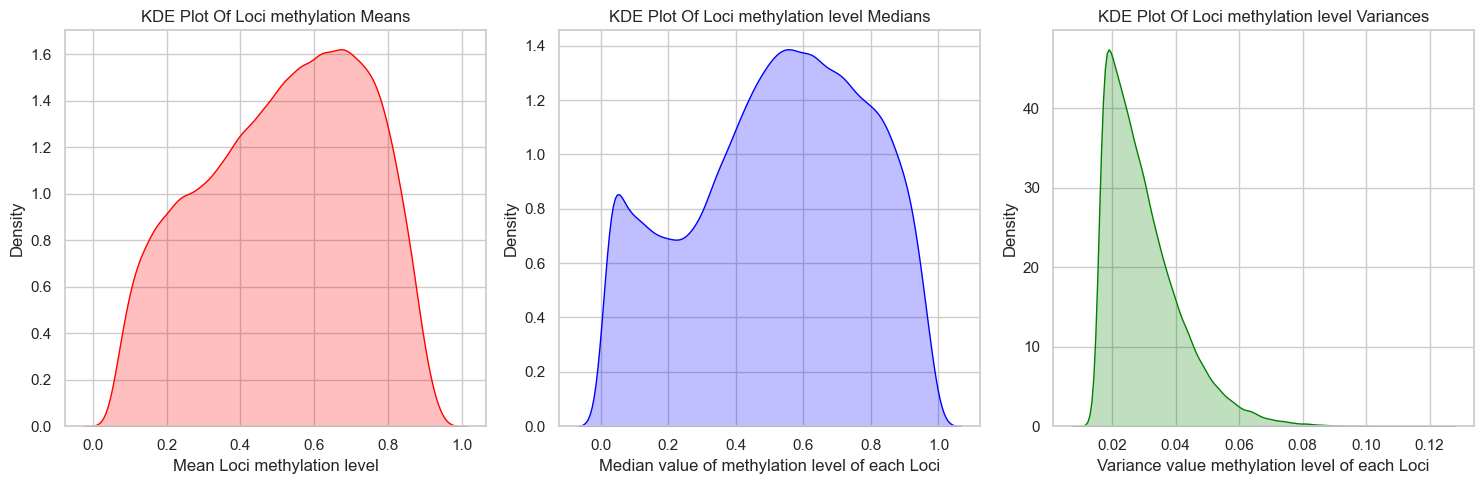

In [114]:
# Print basic dataset information
print("Number of patients in DNAm dataset:", data['DNAm']['meta'].shape[0])
print("Amount of DNA loci (number of features):", data['DNAm']['expr'].shape[1])
# Output indicates there are 500 patients and 100,000 DNA loci measured

# Compute column-wise statistics for the DNAm expression matrix
col_means = data['DNAm']['expr'].mean(axis=0)    # mean methylation per loci
col_median = data['DNAm']['expr'].median(axis=0)  # median methylation per loci
col_var = data['DNAm']['expr'].var(axis=0)       # variance of methylation per loci

# Create a 1x3 subplot for visualizing distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot KDE of mean methylation values per loci
plt.sca(axes[0])
sns.kdeplot(col_means, fill=True, color='red')
plt.title("KDE Plot Of Loci methylation Means")
plt.xlabel("Mean Loci methylation level")
plt.ylabel("Density")

# Plot KDE of median methylation values per loci
plt.sca(axes[1])
sns.kdeplot(col_median, fill=True, color='blue')
plt.title("KDE Plot Of Loci methylation level Medians")
plt.xlabel("Median value of methylation level of each Loci")
plt.ylabel("Density")

# Plot KDE of variance in methylation values per loci
plt.sca(axes[2])
sns.kdeplot(col_var, fill=True, color='green')
plt.title("KDE Plot Of Loci methylation level Variances")
plt.xlabel("Variance value methylation level of each Loci")
plt.ylabel("Density")

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

# Display the plots
plt.show()


We observe a high variability in the mean and median methylation levels across different loci. Variance are all very similar and thus independant from the mean confirming that homoscédasticity is respected.

## PCA

Variance explained by first two components :
[0.29062215 0.07643865]


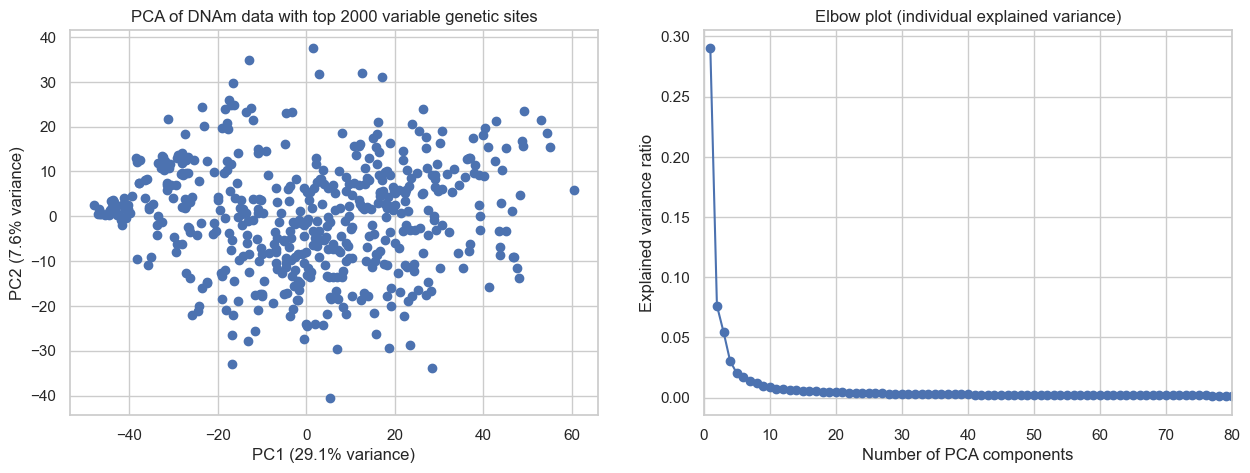

In [115]:
# Extract DNAm expression data


DNAm_df = data['DNAm']['expr']

top__indices = np.argsort(data['DNAm']['expr'].var(axis=0))[-2000:][::-1]                
DNAm_df = DNAm_df.iloc[:, top__indices]

# Standardize the data: mean=0, variance=1 for each protein
scaler = StandardScaler()
DNAm_scaled = scaler.fit_transform(DNAm_df)

# Perform PCA and reduce to 20 principal components
pca = PCA(n_components=10)
principal_components = pca.fit_transform(DNAm_scaled)

# PCA for elbow plot
n_samples = DNAm_scaled.shape[0]
pca_ = PCA(n_components=min(n_samples, DNAm_scaled.shape[1]))
pca_.fit(DNAm_scaled)
explained_var = pca_.explained_variance_ratio_  # Variance explained by each component

# Print variance explained by the first two principal components
print("Variance explained by first two components :")
print(pca.explained_variance_ratio_[:2])

# Create a 1x2 subplot: scatter plot of first two PCs and elbow plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter plot of first two principal components
plt.sca(axes[0])
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA of DNAm data with top 2000 variable genetic sites")
plt.grid(True)

# Elbow plot: visualize explained variance for each PCA component
plt.sca(axes[1])
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o', linestyle='-')
plt.title("Elbow plot (individual explained variance)")
plt.xlabel("Number of PCA components")
plt.ylabel("Explained variance ratio")
plt.xlim(0, 80)
plt.grid(True)


## UMAP

In [116]:
# Extract DNAm expression data
DNAm_df = data['DNAm']['expr']

# Top 2000 variables genetic sites
top_indices = np.argsort(DNAm_df.var(axis=0))[-2000:][::-1]                
DNAm_df = DNAm_df.iloc[:, top_indices]


# Standardize the data: mean=0, variance=1 for each protein
scaler = StandardScaler()
DNAm_scaled = scaler.fit_transform(DNAm_df)

# Reduce dimensionality with PCA before UMAP (retain top 5 components)
pca = PCA(n_components=10, random_state=42)
DNAm_pca = pca.fit_transform(DNAm_scaled)

# Apply UMAP for 2D embedding of the PCA-reduced data
reducer_1 = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
DNAm_umap2d = reducer_1.fit_transform(DNAm_pca)

# Create a DataFrame with UMAP coordinates and PAM50 subtype labels
umap_df_2d = pd.DataFrame(
    DNAm_umap2d,
    columns=['UMAP1', 'UMAP2'],
    index=DNAm_df.index
)
umap_df_2d['paper_BRCA_Subtype_PAM50'] = data['DNAm']['meta'].loc[umap_df_2d.index, 'paper_BRCA_Subtype_PAM50']

# Create an interactive 2D scatter plot using Plotly, coloring points by PAM50 breast cancer subtype
fig = px.scatter(
    umap_df_2d,
    x='UMAP1',
    y='UMAP2',
    color='paper_BRCA_Subtype_PAM50',
    labels={'paper_BRCA_Subtype_PAM50': 'PAM50 Subtype'},
    title='UMAP of DNAm data colored by PAM50 subtype',
    opacity=0.8,
    width=800,
    height=500
)
fig.update_layout(title_font_size=30, legend_title_font_size=24, legend_font_size=20, font=dict(size=18))

fig.show()


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



We can globally observe three clusters. Basal subtype tumours show a very different profile in terme of genes expression (cluster far away from other) from other subtypes. The other tumour subtype Lum A, Lum B and Her present very similar profiles in term of gene expression (their cluster are very near one from the other and overlap). This confirms the need of more advance machine learning techniques in order to distinguish them. We do not observe any strong outliers (i.e., samples far from all clusters). 

## Exploratory Data Analysis (RPPA) (Proteomics)

Number of patients in RPPA dataset: 500
Amount of proteins measured (number of features): 464


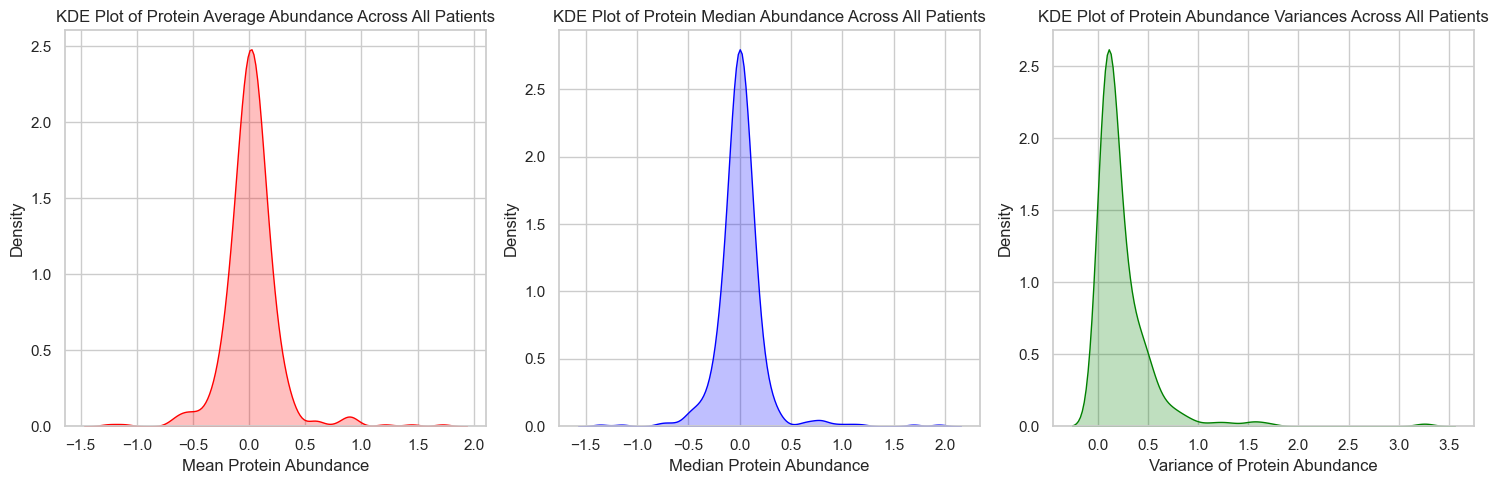

In [117]:
# Print basic information about the RPPA dataset
print("Number of patients in RPPA dataset:", data['RPPA']['meta'].shape[0])  # Number of samples/patients
print("Amount of proteins measured (number of features):", data['RPPA']['expr'].shape[1])  # Number of protein features

# Compute column-wise statistics for the RPPA expression matrix
col_means = data['RPPA']['expr'].mean(axis=0)      # Mean protein abundance per protein across patients
col_median = data['RPPA']['expr'].median(axis=0)   # Median protein abundance per protein
col_var = data['RPPA']['expr'].var(axis=0)         # Variance of protein abundance per protein

# Create a 1x3 subplot for KDE plots of means, medians, and variances
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot KDE of protein-wise means
plt.sca(axes[0])
sns.kdeplot(col_means, fill=True, color='red')
plt.title("KDE Plot of Protein Average Abundance Across All Patients")
plt.xlabel("Mean Protein Abundance")
plt.ylabel("Density")

# Plot KDE of protein-wise medians
plt.sca(axes[1])
sns.kdeplot(col_median, fill=True, color='blue')
plt.title("KDE Plot of Protein Median Abundance Across All Patients")
plt.xlabel("Median Protein Abundance")
plt.ylabel("Density")

# Plot KDE of protein-wise variances
plt.sca(axes[2])
sns.kdeplot(col_var, fill=True, color='green')
plt.title("KDE Plot of Protein Abundance Variances Across All Patients")
plt.xlabel("Variance of Protein Abundance")
plt.ylabel("Density")

# Adjust layout to prevent overlapping elements and display the plots
plt.tight_layout()
plt.show()


Gaussian distributionn probably because of normalisation and standardisation, most of protein have an abundance level arround zéro => so have an abundance level that is equal tout the basic average level of proteins abundance and only few proteins present an abundance level lower or higher the mean or median level. Variance independent from the mean as it is the same for practicly all proteins and thus homoscédasticity conditions are respected.

### PCA

Variance explained by first two components :
[0.15540726 0.10125406]


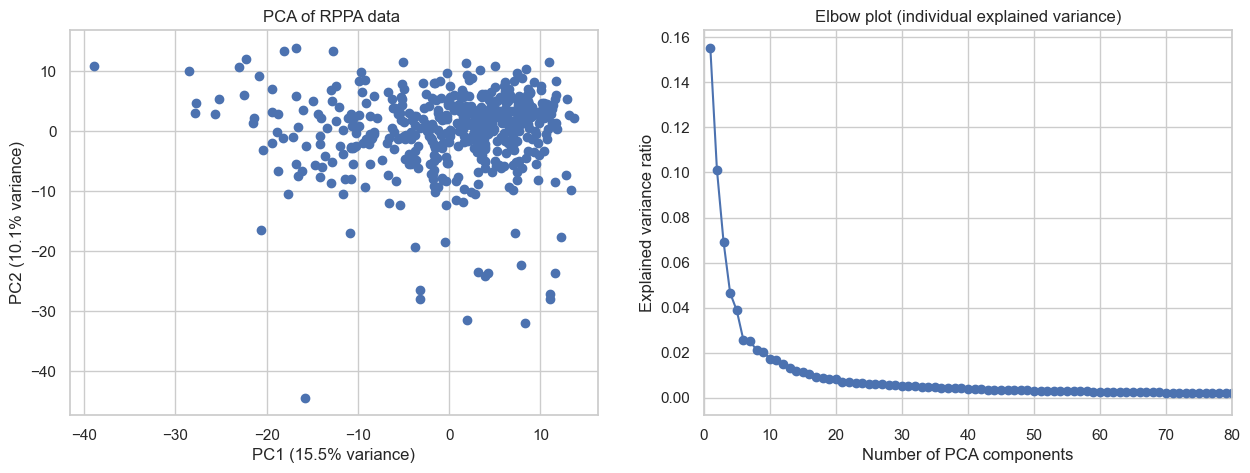

In [118]:
# Extract RPPA expression data
rppa_df = data['RPPA']['expr']

# Standardize the data: mean=0, variance=1 for each protein
scaler = StandardScaler()
rppa_scaled = scaler.fit_transform(rppa_df)

# Perform PCA and reduce to 20 principal components
pca = PCA(n_components=15)
principal_components = pca.fit_transform(rppa_scaled)

# PCA for elbow plot
n_samples = rppa_scaled.shape[0]
pca_ = PCA(n_components=min(n_samples, rppa_scaled.shape[1]))
pca_.fit(rppa_scaled)
explained_var = pca_.explained_variance_ratio_  # Variance explained by each component

# Print variance explained by the first two principal components
print("Variance explained by first two components :")
print(pca.explained_variance_ratio_[:2])

# Create a 1x2 subplot: scatter plot of first two PCs and elbow plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter plot of first two principal components
plt.sca(axes[0])
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA of RPPA data ")
plt.grid(True)

# Elbow plot: visualize explained variance for each PCA component
plt.sca(axes[1])
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o', linestyle='-')
plt.title("Elbow plot (individual explained variance)")
plt.xlabel("Number of PCA components")
plt.ylabel("Explained variance ratio")
plt.xlim(0, 80)
plt.grid(True)


### UMAP

In [119]:
# Extract RPPA expression data
rppa_df = data['RPPA']['expr']

# Standardize the data: mean=0, variance=1 for each protein
scaler = StandardScaler()
rppa_scaled = scaler.fit_transform(rppa_df)

# Reduce dimensionality with PCA before UMAP (retain top 6 components)
pca = PCA(n_components=15, random_state=42)
rppa_pca = pca.fit_transform(rppa_scaled)

# Apply UMAP for 2D embedding of the PCA-reduced data
reducer_1 = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
rppa_umap2d = reducer_1.fit_transform(rppa_pca)

# Create a DataFrame with UMAP coordinates and PAM50 subtype labels
umap_df_2d = pd.DataFrame(
    rppa_umap2d,
    columns=['UMAP1', 'UMAP2'],
    index=rppa_df.index
)
umap_df_2d['paper_BRCA_Subtype_PAM50'] = data['RPPA']['meta'].loc[umap_df_2d.index, 'paper_BRCA_Subtype_PAM50']

# Create an interactive 2D scatter plot using Plotly, coloring points by PAM50 breast cancer subtype
fig = px.scatter(
    umap_df_2d,
    x='UMAP1',
    y='UMAP2',
    color='paper_BRCA_Subtype_PAM50',
    labels={'paper_BRCA_Subtype_PAM50': 'PAM50 Subtype'},
    title='UMAP of RPPA data colored by PAM50 subtype',
    opacity=0.8,
    width=800,
    height=500
)
fig.update_layout(title_font_size=30, legend_title_font_size=24, legend_font_size=20, font=dict(size=18))
fig.show()


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



WWe can globally observe three clusters. Basal subtype tumours show a very different profile in terme of genes expression (cluster far away from other) from other subtypes. The other tumour subtype Lum A, Lum B and Her present very similar profiles in term of gene expression (their cluster are very near one from the other and overlap). This confirms the need of more advance machine learning techniques in order to distinguish them. We do not observe any strong outliers (i.e., samples far from all clusters). 

# Distribution of samples by meta-data (for the ethical risks assessment)

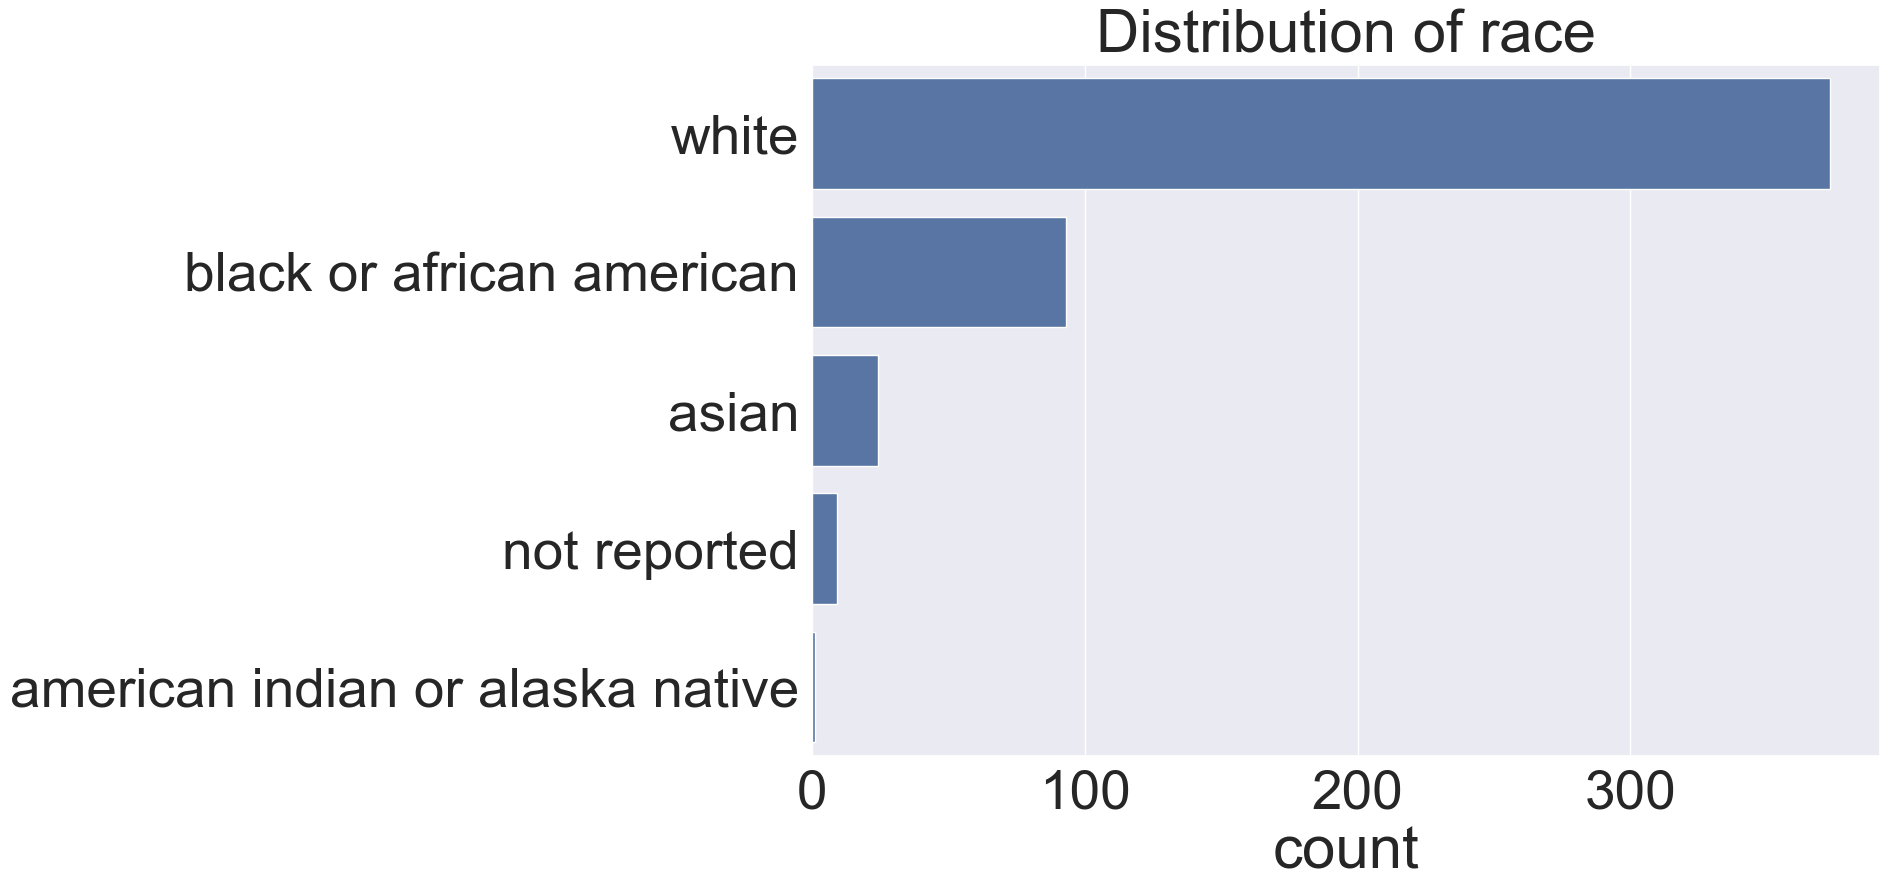

In [120]:
sns.set(font_scale=3.6)

plt.figure(figsize=(20,10))
race_order = data['DNAm']['meta']['race'].value_counts().index

sns.countplot(y='race', data=data['DNAm']['meta'], order=race_order)
plt.ylabel('')
plt.title(f"Distribution of {'race'}")
plt.tight_layout()
plt.show()